# ĐỒ ÁN #21 — Language Modeling Mini

**Họ và tên:** Lê Trọng Pháp (23683011) · Phạm Đỗ Anh Quân (23676261)  
**Môn học:** Deep Learning  
**Giảng viên hướng dẫn:** [Tên GV]

---

| | |
|---|---|
| **Mô hình 1 (Baseline)** | LSTM Language Model |
| **Mô hình 2 (Nâng cao)** | Transformer Decoder Mini |
| **Dataset** | WikiText-2 |
| **Metric** | Perplexity (PPL) |

---

## Mục Lục
1. [Cài đặt & Kiểm tra môi trường](#sec1)
2. [Import thư viện & Cấu hình chung](#sec2)
3. [Tải & Phân tích dữ liệu — WikiText-2](#sec3)
4. [Tokenization (BPE) & Dataset](#sec4)
5. [Mô hình 1 — LSTM Baseline](#sec5)
6. [Mô hình 2 — Transformer Decoder Mini](#sec6)
7. [So sánh kết quả](#sec7)
8. [Thí nghiệm: Optimizer & Regularization](#sec8)
9. [Sinh văn bản & Phân tích lỗi](#sec9)
10. [Kết luận](#sec10)

<a id='sec1'></a>
## 1. Cài đặt & Kiểm tra môi trường

In [1]:
!pip install datasets tokenizers -q

In [2]:
import torch
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("VRAM            :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print(" Không có GPU — vào Runtime > Change runtime type > T4 GPU")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [3]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
SAVE_DIR = Path("/content/drive/MyDrive/do_an_21")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Google Drive đã kết nối. Lưu model tại: {SAVE_DIR}")

Mounted at /content/drive
Google Drive đã kết nối. Lưu model tại: /content/drive/MyDrive/do_an_21


<a id='sec2'></a>
## 2. Import thư viện & Cấu hình chung

In [4]:
import math, os, random, platform
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tokenizers import Tokenizer, models, trainers, pre_tokenizers
from tqdm.notebook import tqdm

print("Import OK")

Import OK


In [5]:
#  CẤU HÌNH CHUNG — chỉnh tại đây để thay đổi toàn bộ

# Dữ liệu
MAX_TRAIN   = -1       # -1 = dùng tất cả | đặt số nguyên để train nhanh hơn (vd: 20000)
MAX_VAL     = -1
MAX_TEST    = -1
BPE_VOCAB   = 10000    # kích thước vocab BPE

# Chung cho cả 2 model
SEQ_LEN     = 128      # độ dài chuỗi — đề bài yêu cầu L=64–128
STRIDE      = 64       # sliding window stride (overlap = SEQ_LEN - STRIDE)
BATCH_SIZE  = 64     # ✅ tăng từ 32 → 64
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 0 if platform.system() == 'Windows' else 2

# Mô hình 1 — LSTM
LSTM_EMBED  = 256
LSTM_HIDDEN = 1024   # ✅ tăng từ 512 → 1024 (model lớn hơn)
LSTM_LAYERS = 2
LSTM_DROP   = 0.5    # ✅ tăng dropout để tránh overfit
LSTM_EPOCHS = 35     # ✅ tăng từ 20 → 35
LSTM_LR     = 5e-4   # ✅ tăng nhẹ để hội tụ nhanh hơn
LSTM_PAT    = 5      # ✅ tăng patience từ 3 → 5        # early stopping patience

# Mô hình 2 — Transformer
TF_DMODEL   = 256      # d=128–256 theo đề bài
TF_HEADS    = 4
TF_LAYERS   = 4        # 2–4 layers theo đề bài
TF_FFN      = 1024   # ✅ tăng từ 512 → 1024 (= 4×d_model, chuẩn GPT)
TF_DROP     = 0.15   # ✅ tăng nhẹ dropout để tránh overfit khi train dài hơn
TF_EPOCHS   = 60     # ✅ tăng từ 40 → 60 (Transformer cần nhiều epoch hơn)
TF_LR       = 5e-4   # ✅ tăng từ 3e-4 → 5e-4 để hội tụ nhanh hơn
TF_PAT      = 8      # ✅ tăng patience từ 6 → 8 để Transformer có đủ thời gian hội tụ

print(f"DEVICE      : {DEVICE}")
print(f"SEQ_LEN     : {SEQ_LEN} | STRIDE : {STRIDE} | BATCH : {BATCH_SIZE}")
print(f"BPE vocab   : {BPE_VOCAB} (+ 2 special tokens = {BPE_VOCAB+2})")

DEVICE      : cuda
SEQ_LEN     : 128 | STRIDE : 64 | BATCH : 64
BPE vocab   : 10000 (+ 2 special tokens = 10002)


In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print("Seed = 42")

Seed = 42


<a id='sec3'></a>
## 3. Tải & Phân tích dữ liệu — WikiText-2

**WikiText-2** là dataset chuẩn cho bài toán Language Modeling:
- Nguồn: các bài viết Wikipedia chất lượng cao (Good + Featured articles)
- Chia sẵn 3 tập: Train / Validation / Test
- Đặc thù: phân phối Zipf (nhiều từ hiếm), câu dài, ngữ cảnh xa

In [7]:
print("Đang tải WikiText-2 từ HuggingFace...")
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

def filter_texts(texts, max_n=-1):
    """Lọc bỏ dòng trống và quá ngắn."""
    result = [t.strip() for t in texts if t and t.strip() and len(t.strip()) >= 20]
    if max_n > 0:
        result = result[:max_n]
    return result

train_texts = filter_texts(dataset['train']['text'],      MAX_TRAIN)
val_texts   = filter_texts(dataset['validation']['text'], MAX_VAL)
test_texts  = filter_texts(dataset['test']['text'],       MAX_TEST)

print(f"\nThống kê số lượng mẫu:")
print(f"   Train      : {len(train_texts):,} đoạn")
print(f"   Validation : {len(val_texts):,} đoạn")
print(f"   Test       : {len(test_texts):,} đoạn")

Đang tải WikiText-2 từ HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]


Thống kê số lượng mẫu:
   Train      : 21,200 đoạn
   Validation : 2,226 đoạn
   Test       : 2,574 đoạn


In [8]:
# Phân tích đặc điểm dataset (word-level, trước BPE)
all_words = ' '.join(train_texts).split()
word_freq = Counter(all_words)

# Thống kê độ dài đoạn văn
doc_lengths = [len(t.split()) for t in train_texts]

print("=== PHÂN TÍCH DATASET WIKITEXT-2 ===")
for name, texts in [('Train', train_texts), ('Validation', val_texts), ('Test', test_texts)]:
    tokens = ' '.join(texts).split()
    print(f"   {name:<12}: {len(texts):,} đoạn | {len(tokens):,} token | "
          f"vocab={len(set(tokens)):,}")

print(f"\nPhân tích đặc thù:")
max_f = max(word_freq.values())
min_f = min(word_freq.values())
print(f"   Imbalance ratio (max/min freq) : {max_f/min_f:,.0f}")
print(f"   Từ chỉ xuất hiện 1 lần         : {sum(1 for c in word_freq.values() if c==1):,}")
print(f"   Độ dài đoạn — min/avg/max       : {min(doc_lengths)} / {np.mean(doc_lengths):.1f} / {max(doc_lengths)}")

print(f"\nNhận xét khó khăn đặc thù:")
print("   1. Phân phối Zipf: imbalance ratio rất cao → nhiều từ hiếm → BPE giải quyết tốt hơn word-level")
print("   2. Long-range dependency: câu Wikipedia dài, cần nhớ ngữ cảnh xa → LSTM gặp khó")
print("   3. Noise: heading '= ... =', token '@-@', dòng trống → cần làm sạch")
print("   4. Không mất cân bằng lớp (LM là next-token prediction, không phân loại)")

=== PHÂN TÍCH DATASET WIKITEXT-2 ===
   Train       : 21,200 đoạn | 2,039,426 token | vocab=76,428
   Validation  : 2,226 đoạn | 212,722 token | vocab=19,836
   Test        : 2,574 đoạn | 239,863 token | vocab=21,050

Phân tích đặc thù:
   Imbalance ratio (max/min freq) : 113,160
   Từ chỉ xuất hiện 1 lần         : 31,999
   Độ dài đoạn — min/avg/max       : 2 / 96.2 / 699

Nhận xét khó khăn đặc thù:
   1. Phân phối Zipf: imbalance ratio rất cao → nhiều từ hiếm → BPE giải quyết tốt hơn word-level
   2. Long-range dependency: câu Wikipedia dài, cần nhớ ngữ cảnh xa → LSTM gặp khó
   3. Noise: heading '= ... =', token '@-@', dòng trống → cần làm sạch
   4. Không mất cân bằng lớp (LM là next-token prediction, không phân loại)


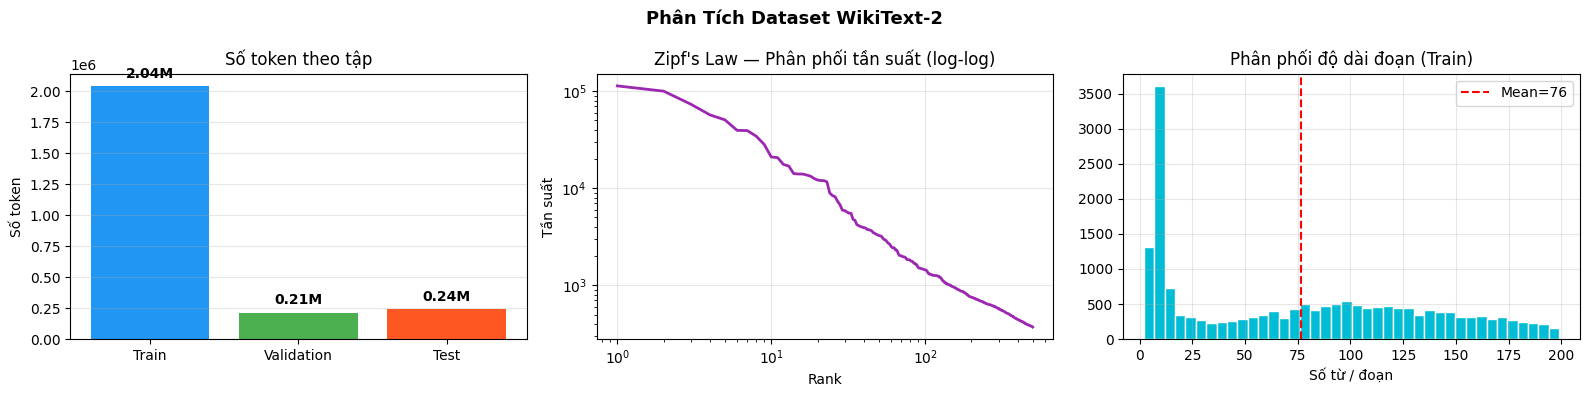

Lưu: eda_dataset.png


In [9]:
# Vẽ 3 biểu đồ EDA
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Phân Tích Dataset WikiText-2', fontsize=13, fontweight='bold')

# Biểu đồ 1: Số token theo tập
split_names   = ['Train', 'Validation', 'Test']
split_texts   = [train_texts, val_texts, test_texts]
token_counts  = [len(' '.join(t).split()) for t in split_texts]
bars = axes[0].bar(split_names, token_counts, color=['#2196F3','#4CAF50','#FF5722'])
axes[0].bar_label(bars, labels=[f'{c/1e6:.2f}M' for c in token_counts], padding=4, fontweight='bold')
axes[0].set_title('Số token theo tập'); axes[0].set_ylabel('Số token')
axes[0].grid(axis='y', alpha=0.3)

# Biểu đồ 2: Zipf's Law
freqs = sorted(word_freq.values(), reverse=True)[:500]
axes[1].loglog(range(1, len(freqs)+1), freqs, color='#9C27B0', lw=2)
axes[1].set_title("Zipf's Law — Phân phối tần suất (log-log)")
axes[1].set_xlabel('Rank'); axes[1].set_ylabel('Tần suất')
axes[1].grid(True, alpha=0.3)

# Biểu đồ 3: Phân phối độ dài đoạn
lens_clip = [l for l in doc_lengths if l < 200]
axes[2].hist(lens_clip, bins=40, color='#00BCD4', edgecolor='white')
axes[2].axvline(np.mean(lens_clip), color='red', ls='--',
                label=f'Mean={np.mean(lens_clip):.0f}')
axes[2].set_title('Phân phối độ dài đoạn (Train)')
axes[2].set_xlabel('Số từ / đoạn'); axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'eda_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lưu: eda_dataset.png")

<a id='sec4'></a>
## 4. Tokenization (BPE) & Dataset

**BPE (Byte Pair Encoding)** được chọn thay cho word-level vì:
- Không có `<unk>` — mọi từ đều được biểu diễn qua subword
- Vocab nhỏ hơn (~10,000) so với word-level (~33,000)
- Xử lý tốt từ hiếm và từ ghép

**Pipeline:**
```
Raw Text → filter_texts() → BPE Tokenizer (vocab=10,000)
  → LMDataset (sliding window, stride=64)
  → DataLoader (batch=64, shuffle=True)
```

In [10]:
# Huấn luyện BPE Tokenizer trên tập train
from tokenizers import AddedToken

print("Đang train BPE tokenizer...")
tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

trainer = trainers.BpeTrainer(
    vocab_size        = BPE_VOCAB,
    special_tokens    = ["<pad>", "<unk>"],
    show_progress     = True
)
tokenizer.train_from_iterator(train_texts, trainer)

bpe_vocab = tokenizer.get_vocab()
PAD_ID    = bpe_vocab["<pad>"]
UNK_ID    = bpe_vocab["<unk>"]
VOCAB_SIZE = tokenizer.get_vocab_size()
id2token  = {v: k for k, v in bpe_vocab.items()}

# Lưu tokenizer để dùng lại
tokenizer.save(str(SAVE_DIR / 'bpe_tokenizer.json'))

def encode(text): return tokenizer.encode(text).ids
def decode(ids):  return tokenizer.decode(ids)

print(f"\nBPE Tokenizer sẵn sàng")
print(f"   VOCAB_SIZE : {VOCAB_SIZE:,}")
print(f"   PAD_ID     : {PAD_ID}")
print(f"   UNK_ID     : {UNK_ID}")

# Kiểm tra encode/decode
sample  = "the history of the world"
encoded = encode(sample)
decoded = decode(encoded)
print(f"\n   Encode: '{sample}'")
print(f"   → IDs  : {encoded}")
print(f"   → Decode: '{decoded}'")

Đang train BPE tokenizer...

BPE Tokenizer sẵn sàng
   VOCAB_SIZE : 10,000
   PAD_ID     : 0
   UNK_ID     : 1

   Encode: 'the history of the world'
   → IDs  : [1013, 2184, 1026, 1013, 1946]
   → Decode: 'the history of the world'


In [11]:
# Thống kê sau BPE
print("Thống kê token sau BPE tokenization:")
for name, texts in [('Train', train_texts), ('Validation', val_texts), ('Test', test_texts)]:
    # Sample 500 đoạn để ước tính nhanh
    sample_n = min(500, len(texts))
    sample_t = random.sample(texts, sample_n)
    total_tok = sum(len(encode(t)) for t in sample_t)
    avg_tok   = total_tok / sample_n
    est_total = int(avg_tok * len(texts))
    print(f"   {name:<12}: ~{est_total:,} tokens (avg {avg_tok:.1f} tok/đoạn)")

# Top-20 BPE token phổ biến
bpe_counter = Counter()
for t in train_texts[:2000]:
    bpe_counter.update(encode(t))

top20 = bpe_counter.most_common(20)
print(f"\nTop-20 BPE token phổ biến nhất:")
for tid, cnt in top20:
    print(f"   '{id2token.get(tid, '?')}'  →  {cnt:,}")

Thống kê token sau BPE tokenization:
   Train       : ~2,435,201 tokens (avg 114.9 tok/đoạn)
   Validation  : ~267,538 tokens (avg 120.2 tok/đoạn)
   Test        : ~298,424 tokens (avg 115.9 tok/đoạn)

Top-20 BPE token phổ biến nhất:
   'the'  →  10,928
   ','  →  10,231
   '.'  →  7,536
   'of'  →  5,540
   'and'  →  4,994
   'in'  →  4,288
   'a'  →  3,859
   'to'  →  3,779
   '"'  →  2,565
   's'  →  2,183
   '='  →  2,163
   'was'  →  2,117
   '@-@'  →  1,839
   'as'  →  1,588
   '''  →  1,577
   'The'  →  1,576
   'on'  →  1,512
   'for'  →  1,450
   'that'  →  1,446
   'with'  →  1,353


In [12]:
# Dataset với sliding window (stride=64, overlap=64)
class LMDataset(Dataset):
    """
    Language Model Dataset — sliding window.
    Mỗi sample: x = tokens[i : i+seq_len], y = tokens[i+1 : i+seq_len+1]
    stride < seq_len → overlap, model thấy nhiều ngữ cảnh hơn.
    """
    def __init__(self, texts, seq_len, stride=None):
        self.seq_len = seq_len
        self.stride  = stride if stride is not None else seq_len

        # Nối tất cả đoạn thành 1 chuỗi token dài
        all_tokens = []
        for text in texts:
            all_tokens.extend(encode(text))
        self.data = torch.tensor(all_tokens, dtype=torch.long)

        # Số sample có thể lấy
        self.n = max(0, (len(self.data) - seq_len - 1) // self.stride)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        start = idx * self.stride
        x = self.data[start     : start + self.seq_len]
        y = self.data[start + 1 : start + self.seq_len + 1]
        return x, y


print("Đang tạo Dataset (sliding window, stride=64)...")
train_dataset = LMDataset(train_texts, SEQ_LEN, STRIDE)
val_dataset   = LMDataset(val_texts,   SEQ_LEN, STRIDE)
test_dataset  = LMDataset(test_texts,  SEQ_LEN, STRIDE)

pin = (DEVICE.type == 'cuda')
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True,
                          pin_memory=pin, num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_dataset,   BATCH_SIZE, shuffle=False,
                          pin_memory=pin, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  BATCH_SIZE, shuffle=False,
                          pin_memory=pin, num_workers=NUM_WORKERS)

print(f"\nDataset sẵn sàng:")
print(f"   Train : {len(train_dataset):,} samples")
print(f"   Valid : {len(val_dataset):,} samples")
print(f"   Test  : {len(test_dataset):,} samples")
print(f"   Batch shape: x={BATCH_SIZE}×{SEQ_LEN}, y={BATCH_SIZE}×{SEQ_LEN}")

# Kiểm tra 1 batch
xb, yb = next(iter(train_loader))
print(f"\n   Batch x : {list(xb.shape)}  dtype={xb.dtype}")
print(f"   Batch y : {list(yb.shape)}  (y = x dịch phải 1 vị trí)")
print(f"   Decode mẫu x[0][:10]: '{decode(xb[0][:10].tolist())}'")

Đang tạo Dataset (sliding window, stride=64)...

Dataset sẵn sàng:
   Train : 39,589 samples
   Valid : 4,182 samples
   Test  : 4,795 samples
   Batch shape: x=64×128, y=64×128

   Batch x : [64, 128]  dtype=torch.int64
   Batch y : [64, 128]  (y = x dịch phải 1 vị trí)
   Decode mẫu x[0][:10]: 'ern ale . He also tran scribed two pieces from'


In [13]:
# Hàm đánh giá và Early Stopping — dùng chung cho cả 2 model
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

def evaluate(model, loader):
    """
    Tính average token-level cross-entropy loss và Perplexity.
    PPL = exp(avg_loss) — thấp hơn = model tốt hơn.
    """
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)                              # (B, T, V)
            loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
            total_loss   += loss.item() * y.numel()
            total_tokens += y.numel()
    avg_loss = total_loss / max(total_tokens, 1)
    ppl      = math.exp(min(avg_loss, 20))                 # clip tránh overflow
    return avg_loss, ppl


class EarlyStopping:
    """Dừng training khi val_loss không cải thiện sau `patience` epoch liên tiếp."""
    def __init__(self, patience=3, save_path=None, name='model'):
        self.patience   = patience
        self.save_path  = save_path
        self.name       = name
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_epoch = 0

    def __call__(self, val_loss, model, epoch):
        if val_loss < self.best_loss - 1e-4:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_epoch = epoch
            if self.save_path:
                torch.save(model.state_dict(), self.save_path)
                print(f"   [{self.name}] Best saved — "
                      f"val_ppl={math.exp(min(val_loss,20)):.2f} (epoch {epoch})")
            return False   # chưa dừng
        else:
            self.counter += 1
            print(f"  [{self.name}] No improve ({self.counter}/{self.patience})")
            return self.counter >= self.patience  # True → dừng

use_amp = (DEVICE.type == 'cuda')
print("evaluate() và EarlyStopping sẵn sàng")
print(f"   Mixed-precision (AMP): {'ON' if use_amp else 'OFF'}")

evaluate() và EarlyStopping sẵn sàng
   Mixed-precision (AMP): ON


<a id='sec5'></a>
## 5. Mô hình 1 — LSTM Language Model (Baseline)

### Kiến trúc
```
Input (B=64, T=128)
  → Embedding(10002, 256)           # token id → vector 256-dim
  → 2-layer LSTM(256→1024, drop=0.5) # học tuần tự, hidden state
  → Dropout(0.5)                    # regularization
  → Linear(1024, 10002)             # project → logits
  → logits (B, T, 10002)
```

| Layer | Shape đầu ra | Vai trò |
|---|---|---|
| Embedding | (B, T, 256) | Token ID → vector liên tục |
| LSTM × 2 | (B, T, 1024) | Học phụ thuộc tuần tự |
| Dropout(0.5) | (B, T, 1024) | Tránh overfit |
| Linear(1024→10002) | (B, T, 10002) | Logit dự đoán token tiếp theo |

In [14]:
class LSTM_LM(nn.Module):
    """
    LSTM Language Model (Baseline).
    Kiến trúc: Embedding → 2-layer LSTM → Dropout → Linear → logits.
    """
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm      = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True
        )
        self.dropout = nn.Dropout(dropout)   # ✅ dùng tham số nhất quán thay vì hardcode 0.4
        self.fc      = nn.Linear(hidden_dim, vocab_size)
        self._init_weights()

    def _init_weights(self):
        """Khởi tạo trọng số cẩn thận để hội tụ tốt hơn."""
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.zeros_(self.fc.bias)
        for name, p in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)   # input-hidden: Xavier
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)       # hidden-hidden: Orthogonal → giảm vanishing gradient
            elif 'bias' in name:
                nn.init.zeros_(p)

    def forward(self, x):
        # x: (B, T) — token IDs
        emb    = self.embedding(x)    # (B, T, embed_dim)
        out, _ = self.lstm(emb)       # (B, T, hidden_dim)
        # _ bỏ qua (h_n, c_n) — mỗi batch là sequence độc lập
        out    = self.dropout(out)
        return self.fc(out)           # (B, T, vocab_size)


lstm_model = LSTM_LM(
    vocab_size = VOCAB_SIZE,
    embed_dim  = LSTM_EMBED,
    hidden_dim = LSTM_HIDDEN,
    num_layers = LSTM_LAYERS,
    dropout    = LSTM_DROP
).to(DEVICE)

n_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"LSTM LM khởi tạo xong")
print(f"   Tổng tham số : {n_lstm:,}")
print(f"   Embedding    : {VOCAB_SIZE} × {LSTM_EMBED} = {VOCAB_SIZE*LSTM_EMBED:,}")
print(f"   LSTM (2L)    : embed={LSTM_EMBED}, hidden={LSTM_HIDDEN}")

LSTM LM khởi tạo xong
   Tổng tham số : 26,457,872
   Embedding    : 10000 × 256 = 2,560,000
   LSTM (2L)    : embed=256, hidden=1024


In [15]:
# Optimizer & Scheduler
lstm_optimizer  = optim.Adam(lstm_model.parameters(), lr=LSTM_LR, weight_decay=1e-4)
lstm_scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    lstm_optimizer, mode='min', factor=0.5, patience=2
)
lstm_early_stop = EarlyStopping(
    patience  = LSTM_PAT,
    save_path = SAVE_DIR / 'lstm_best.pt',
    name      = 'LSTM'
)

lstm_history = []
scaler_lstm  = torch.amp.GradScaler('cuda') if use_amp else None

print(f"Train LSTM — max {LSTM_EPOCHS} epoch | early stop patience={LSTM_PAT}")
print(f"   Optimizer : Adam (lr={LSTM_LR}) + ReduceLROnPlateau")
print(f"   Grad clip : 0.5")
print('=' * 68)

for epoch in range(1, LSTM_EPOCHS + 1):
    lstm_model.train()
    total_loss = 0.0

    for x, y in tqdm(train_loader, desc=f'[LSTM] Epoch {epoch}/{LSTM_EPOCHS}', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        lstm_optimizer.zero_grad()

        if use_amp:
            with torch.amp.autocast('cuda'):
                logits = lstm_model(x)
                loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
            scaler_lstm.scale(loss).backward()
            scaler_lstm.unscale_(lstm_optimizer)
            torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 0.5)
            scaler_lstm.step(lstm_optimizer)
            scaler_lstm.update()
        else:
            logits = lstm_model(x)
            loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 0.5)
            lstm_optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_ppl  = math.exp(min(train_loss, 20))
    val_loss, val_ppl = evaluate(lstm_model, val_loader)
    lstm_scheduler.step(val_loss)
    lr = lstm_optimizer.param_groups[0]['lr']

    lstm_history.append(dict(
        epoch=epoch, train_loss=train_loss, val_loss=val_loss,
        train_ppl=train_ppl, val_ppl=val_ppl, lr=lr
    ))
    print(f"Epoch {epoch:02d}/{LSTM_EPOCHS} | "
          f"Train PPL: {train_ppl:7.2f} | Val PPL: {val_ppl:7.2f} | LR: {lr:.2e}")

    if lstm_early_stop(val_loss, lstm_model, epoch):
        print(f"\nEarly Stopping tại epoch {epoch} | Best epoch: {lstm_early_stop.best_epoch}")
        break

print(f"\nLSTM train xong! Best Val PPL = "
      f"{math.exp(min(lstm_early_stop.best_loss,20)):.2f} (epoch {lstm_early_stop.best_epoch})")

Train LSTM — max 35 epoch | early stop patience=5
   Optimizer : Adam (lr=0.0005) + ReduceLROnPlateau
   Grad clip : 0.5


[LSTM] Epoch 1/35:   0%|          | 0/618 [00:00<?, ?it/s]

Epoch 01/35 | Train PPL:  905.73 | Val PPL:  550.95 | LR: 5.00e-04
   [LSTM] Best saved — val_ppl=550.95 (epoch 1)


[LSTM] Epoch 2/35:   0%|          | 0/618 [00:00<?, ?it/s]

Epoch 02/35 | Train PPL:  448.44 | Val PPL:  382.25 | LR: 5.00e-04
   [LSTM] Best saved — val_ppl=382.25 (epoch 2)


...

Epoch 08/35 | Train PPL:  339.34 | Val PPL:  347.20 | LR: 2.50e-04
  [LSTM] No improve (3/5)


[LSTM] Epoch 9/35:   0%|          | 0/618 [00:00<?, ?it/s]

Epoch 09/35 | Train PPL:  328.90 | Val PPL:  329.96 | LR: 2.50e-04
  [LSTM] No improve (4/5)


[LSTM] Epoch 10/35:   0%|          | 0/618 [00:00<?, ?it/s]

Epoch 10/35 | Train PPL:  334.81 | Val PPL:  346.00 | LR: 2.50e-04
  [LSTM] No improve (5/5)

Early Stopping tại epoch 10 | Best epoch: 5

LSTM train xong! Best Val PPL = 329.65 (epoch 5)


In [16]:
# Load best LSTM & đánh giá trên val + test
lstm_model.load_state_dict(
    torch.load(SAVE_DIR / 'lstm_best.pt', map_location=DEVICE, weights_only=True)
)
lstm_val_loss,  lstm_val_ppl  = evaluate(lstm_model, val_loader)
lstm_test_loss, lstm_test_ppl = evaluate(lstm_model, test_loader)

print(f"[LSTM] Val  Loss: {lstm_val_loss:.4f}  →  Val  PPL: {lstm_val_ppl:.2f}")
print(f"[LSTM] Test Loss: {lstm_test_loss:.4f}  →  Test PPL: {lstm_test_ppl:.2f}")

[LSTM] Val  Loss: 5.7980  →  Val  PPL: 329.65
[LSTM] Test Loss: 5.8097  →  Test PPL: 333.51


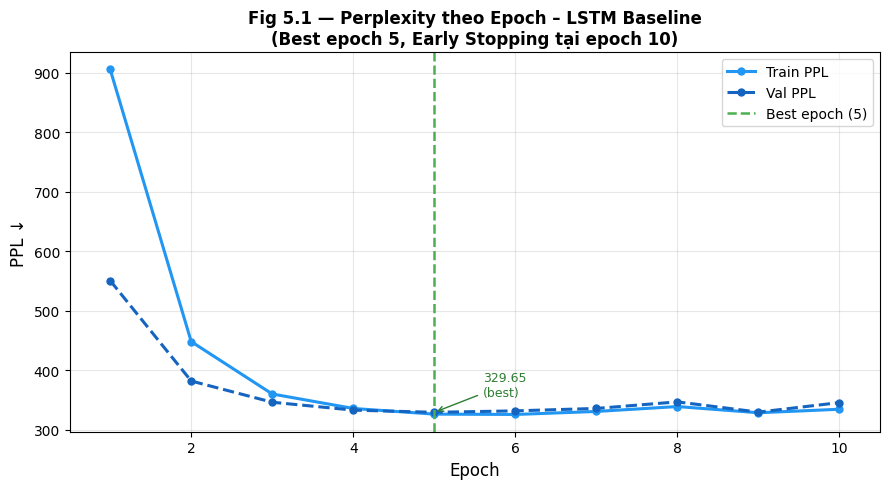

Saved: fig5_1_lstm_ppl.png


In [17]:
# ── Fig 5.1 ── Perplexity theo epoch – LSTM
import matplotlib.pyplot as plt

ep        = [h['epoch']     for h in lstm_history]
tr_ppl    = [h['train_ppl'] for h in lstm_history]
vl_ppl    = [h['val_ppl']   for h in lstm_history]
best_ep   = lstm_early_stop.best_epoch

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ep, tr_ppl, 'o-',  color='#2196F3', lw=2.2, ms=5, label='Train PPL')
ax.plot(ep, vl_ppl, 'o--', color='#1565C0', lw=2.2, ms=5, label='Val PPL')
ax.axvline(best_ep, color='#4CAF50', ls='--', lw=1.8, label=f'Best epoch ({best_ep})')
bv = vl_ppl[best_ep - 1]
ax.annotate(f'{bv:.2f}\n(best)', xy=(best_ep, bv),
            xytext=(best_ep + 0.6, bv + max(vl_ppl)*0.05),
            fontsize=9, color='#2e7d32',
            arrowprops=dict(arrowstyle='->', color='#2e7d32'))
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('PPL ↓', fontsize=12)
ax.set_title(f'Fig 5.1 — Perplexity theo Epoch – LSTM Baseline\n'
             f'(Best epoch {best_ep}, Early Stopping tại epoch {ep[-1]})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, ep[-1] + 0.5)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig5_1_lstm_ppl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_1_lstm_ppl.png")


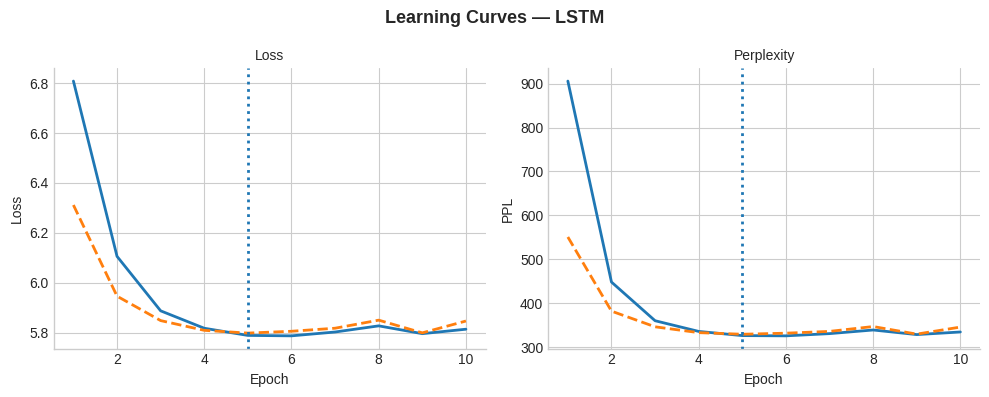

In [33]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

ep      = [h['epoch'] for h in lstm_history]
tr_loss = [h['train_loss'] for h in lstm_history]
vl_loss = [h['val_loss'] for h in lstm_history]
tr_ppl  = [h['train_ppl'] for h in lstm_history]
vl_ppl  = [h['val_ppl'] for h in lstm_history]

best_ep = lstm_early_stop.best_epoch

plt.figure(figsize=(10,4))

# title tổng
plt.suptitle("Learning Curves — LSTM", fontsize=13, fontweight='bold')

# --- Loss ---
ax1 = plt.subplot(1,2,1)
ax1.plot(ep, tr_loss, linewidth=2)
ax1.plot(ep, vl_loss, linewidth=2, linestyle='--')
ax1.axvline(best_ep, linestyle=':', linewidth=2)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss", fontsize=10)

ax1.spines[['top','right']].set_visible(False)

# --- PPL ---
ax2 = plt.subplot(1,2,2)
ax2.plot(ep, tr_ppl, linewidth=2)
ax2.plot(ep, vl_ppl, linewidth=2, linestyle='--')
ax2.axvline(best_ep, linestyle=':', linewidth=2)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("PPL")
ax2.set_title("Perplexity", fontsize=10)

ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

<a id='sec6'></a>
## 6. Mô hình 2 — Transformer Decoder Mini (Nâng cao)

### Kiến trúc
```
Input (B=64, T=128)
  → Embedding(10002, 256) × sqrt(256)   # scaled embedding
  → Positional Encoding (sinusoidal)     # vị trí token trong chuỗi
  → 4 × TransformerBlock:
       Pre-LayerNorm → Multi-Head Attention (4 heads, causal mask)
       Pre-LayerNorm → FFN (256→1024→256, GELU)
  → LayerNorm
  → Linear(256, 10002)  ← weight tied với Embedding
  → logits (B, T, 10002)
```

**Cải tiến so với LSTM:**
- **Causal mask**: token i chỉ attend token 0..i → đúng với next-token prediction
- **Pre-LayerNorm** (`norm_first=True`): gradient ổn định hơn Post-LN
- **Weight tying**: Linear dùng chung weight với Embedding → giảm tham số, tăng generalization
- **AdamW + Warmup + Cosine Decay**: LR tăng dần 2 epoch rồi giảm theo cosine

In [19]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding (Vaswani et al., 2017).
    PE(pos, 2i)   = sin(pos / 10000^(2i/d))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d))
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerLM(nn.Module):
    """
    Transformer Decoder-only Language Model (GPT-style).
    Dùng TransformerEncoderLayer với causal mask → thực chất là Decoder.
    """
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=4,
                 ffn_dim=512, dropout=0.1, max_len=512):
        super().__init__()
        self.d_model   = d_model
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = ffn_dim,
            dropout         = dropout,
            activation      = 'gelu',   # GELU tốt hơn ReLU cho LM
            batch_first     = True,
            norm_first      = True      # Pre-LN: ổn định gradient hơn Post-LN
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers = n_layers,
            norm       = nn.LayerNorm(d_model)
        )

        # Weight tying: output projection dùng chung weight với Embedding
        self.fc        = nn.Linear(d_model, vocab_size, bias=False)
        self.fc.weight = self.embedding.weight
        self._init_weights()

    def _init_weights(self):
        """Khởi tạo trọng số để ổn định gradient từ epoch đầu.
        Lưu ý: self.fc.weight được tied với self.embedding.weight,
        nên chỉ init embedding 1 lần và SKIP fc trong vòng lặp.
        """
        # 1. Init embedding bằng normal(0, 0.02) — chuẩn GPT
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.02)
        # Pad token = 0 để không contribute vào gradient
        if self.embedding.padding_idx is not None:
            nn.init.zeros_(self.embedding.weight[self.embedding.padding_idx])

        # 2. Init các Linear trong transformer blocks — SKIP self.fc (weight-tied)
        for module in self.modules():
            if isinstance(module, nn.Linear) and module is not self.fc:
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    @staticmethod
    def make_causal_mask(seq_len, device):
        """Ma trận causal: token i chỉ attend token 0..i (không nhìn tương lai)."""
        return torch.triu(
            torch.full((seq_len, seq_len), float('-inf'), device=device),
            diagonal=1
        )

    def forward(self, x):
        # x: (B, T)
        mask = self.make_causal_mask(x.size(1), x.device)
        emb  = self.pos_enc(self.embedding(x) * math.sqrt(self.d_model))
        out  = self.transformer(emb, mask=mask, is_causal=True)
        return self.fc(out)    # (B, T, vocab_size)


tf_model = TransformerLM(
    vocab_size = VOCAB_SIZE,
    d_model    = TF_DMODEL,
    n_heads    = TF_HEADS,
    n_layers   = TF_LAYERS,
    ffn_dim    = TF_FFN,
    dropout    = TF_DROP
).to(DEVICE)

n_tf = sum(p.numel() for p in tf_model.parameters() if p.requires_grad)
print(f"Transformer LM khởi tạo xong")
print(f"   Tổng tham số : {n_tf:,}")
print(f"   d_model={TF_DMODEL} | {TF_HEADS} heads | {TF_LAYERS} layers | FFN={TF_FFN}")
print(f"   Weight tying : Linear output chia sẻ weight với Embedding")

Transformer LM khởi tạo xong
   Tổng tham số : 5,719,552
   d_model=256 | 4 heads | 4 layers | FFN=1024
   Weight tying : Linear output chia sẻ weight với Embedding


/tmp/ipykernel_1536/817316049.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [20]:
# AdamW + Linear Warmup (2 epoch) + Cosine Decay
total_steps  = len(train_loader) * TF_EPOCHS
warmup_steps = len(train_loader) * 2   # ✅ warmup 2 epoch — đủ ổn định, không làm chậm hội tụ

tf_optimizer = optim.AdamW(
    tf_model.parameters(),
    lr           = TF_LR,
    weight_decay = 0.1,
    betas        = (0.9, 0.95)
)

def lr_lambda(step):
    """Warmup tuyến tính từ 1e-6 → LR_max trong 2 epoch, sau đó cosine decay về 1%."""
    min_lr_ratio = 0.01   # LR tối thiểu = 1% của LR_max
    if step < warmup_steps:
        # Bắt đầu từ lr rất nhỏ (1e-6/TF_LR ≈ 0.002) thay vì từ 0
        start_ratio = 1e-6 / TF_LR
        return start_ratio + (1.0 - start_ratio) * step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(min_lr_ratio, 0.5 * (1.0 + math.cos(math.pi * progress)))

tf_scheduler   = optim.lr_scheduler.LambdaLR(tf_optimizer, lr_lambda)
tf_early_stop  = EarlyStopping(
    patience  = TF_PAT,
    save_path = SAVE_DIR / 'tf_best.pt',
    name      = 'TF'
)

tf_history  = []
scaler_tf   = torch.amp.GradScaler('cuda') if use_amp else None
global_step = 0

print(f"Train Transformer — max {TF_EPOCHS} epoch | early stop patience={TF_PAT}")
print(f"   Optimizer : AdamW (lr={TF_LR}, wd=0.1) + Warmup(2ep, start=1e-6) + Cosine Decay")
print(f"   Grad clip : 1.0")
print('=' * 68)

for epoch in range(1, TF_EPOCHS + 1):
    tf_model.train()
    total_loss = 0.0

    for x, y in tqdm(train_loader, desc=f'[TF] Epoch {epoch}/{TF_EPOCHS}', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        tf_optimizer.zero_grad()

        if use_amp:
            with torch.amp.autocast('cuda'):
                logits = tf_model(x)
                loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
            scaler_tf.scale(loss).backward()
            scaler_tf.unscale_(tf_optimizer)
            torch.nn.utils.clip_grad_norm_(tf_model.parameters(), 1.0)
            scaler_tf.step(tf_optimizer)
            scaler_tf.update()
        else:
            logits = tf_model(x)
            loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(tf_model.parameters(), 1.0)
            tf_optimizer.step()

        tf_scheduler.step()
        global_step += 1
        total_loss  += loss.item()

    train_loss = total_loss / len(train_loader)
    train_ppl  = math.exp(min(train_loss, 20))
    val_loss, val_ppl = evaluate(tf_model, val_loader)
    lr = tf_optimizer.param_groups[0]['lr']

    tf_history.append(dict(
        epoch=epoch, train_loss=train_loss, val_loss=val_loss,
        train_ppl=train_ppl, val_ppl=val_ppl, lr=lr
    ))
    print(f"Epoch {epoch:02d}/{TF_EPOCHS} | "
          f"Train PPL: {train_ppl:7.2f} | Val PPL: {val_ppl:7.2f} | LR: {lr:.2e}")

    if tf_early_stop(val_loss, tf_model, epoch):
        print(f"\nEarly Stopping tại epoch {epoch} | Best epoch: {tf_early_stop.best_epoch}")
        break

print(f"\nTransformer train xong! Best Val PPL = "
      f"{math.exp(min(tf_early_stop.best_loss,20)):.2f} (epoch {tf_early_stop.best_epoch})")

Train Transformer — max 60 epoch | early stop patience=8
   Optimizer : AdamW (lr=0.0005, wd=0.1) + Warmup(2ep, start=1e-6) + Cosine Decay
   Grad clip : 1.0


[TF] Epoch 1/60:   0%|          | 0/618 [00:00<?, ?it/s]

Epoch 01/60 | Train PPL: 1571.53 | Val PPL:  552.59 | LR: 2.51e-04
   [TF] Best saved — val_ppl=552.59 (epoch 1)


[TF] Epoch 2/60:   0%|          | 0/618 [00:00<?, ?it/s]

Epoch 02/60 | Train PPL:  383.35 | Val PPL:  275.46 | LR: 5.00e-04
   [TF] Best saved — val_ppl=275.46 (epoch 2)


...

Epoch 58/60 | Train PPL:   43.26 | Val PPL:   96.49 | LR: 5.00e-06
  [TF] No improve (1/8)


[TF] Epoch 59/60:   0%|          | 0/618 [00:00<?, ?it/s]

Epoch 59/60 | Train PPL:   43.24 | Val PPL:   96.51 | LR: 5.00e-06
  [TF] No improve (2/8)


[TF] Epoch 60/60:   0%|          | 0/618 [00:00<?, ?it/s]

Epoch 60/60 | Train PPL:   43.23 | Val PPL:   96.49 | LR: 5.00e-06
  [TF] No improve (3/8)

Transformer train xong! Best Val PPL = 96.47 (epoch 57)


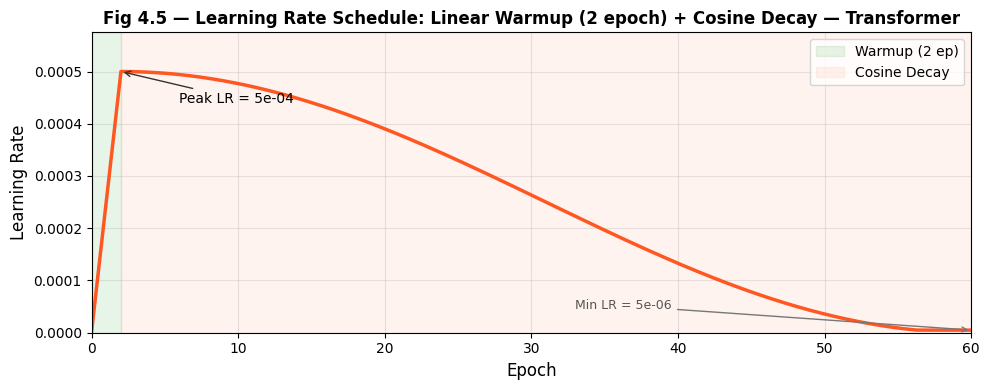

Saved: fig4_5_lr_schedule.png


In [21]:
# ── Fig 4.5 ── LR Schedule: Linear Warmup (2 ep) + Cosine Decay
import numpy as np
import matplotlib.pyplot as plt

_total  = len(train_loader) * TF_EPOCHS
_warmup = len(train_loader) * 2

def _lr(step):
    if step < _warmup:
        return (1e-6/TF_LR) + (1 - 1e-6/TF_LR) * step / max(1, _warmup)
    prog = (step - _warmup) / max(1, _total - _warmup)
    return max(0.01, 0.5 * (1 + np.cos(np.pi * prog)))

steps     = np.arange(0, _total + 1)
lr_vals   = np.array([TF_LR * _lr(s) for s in steps])
epoch_ax  = steps / len(train_loader)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axvspan(0, 2, alpha=0.13, color='#4CAF50', label='Warmup (2 ep)')
ax.axvspan(2, TF_EPOCHS, alpha=0.07, color='#FF5722', label='Cosine Decay')
ax.plot(epoch_ax, lr_vals, color='#FF5722', lw=2.5)
ax.annotate(f'Peak LR = {TF_LR:.0e}', xy=(2, TF_LR),
            xytext=(6, TF_LR * 0.88),
            arrowprops=dict(arrowstyle='->', color='#333'), fontsize=10)
ax.annotate(f'Min LR = {TF_LR*0.01:.0e}', xy=(TF_EPOCHS, TF_LR*0.01),
            xytext=(TF_EPOCHS*0.55, TF_LR*0.09),
            arrowprops=dict(arrowstyle='->', color='#777'), fontsize=9, color='#555')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Learning Rate', fontsize=12)
ax.set_title('Fig 4.5 — Learning Rate Schedule: Linear Warmup (2 epoch) + Cosine Decay — Transformer',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, TF_EPOCHS); ax.set_ylim(0, TF_LR * 1.15)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig4_5_lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_5_lr_schedule.png")


In [22]:
# Load best Transformer & đánh giá
tf_model.load_state_dict(
    torch.load(SAVE_DIR / 'tf_best.pt', map_location=DEVICE, weights_only=True)
)
tf_val_loss,  tf_val_ppl  = evaluate(tf_model, val_loader)
tf_test_loss, tf_test_ppl = evaluate(tf_model, test_loader)

print(f"[Transformer] Val  Loss: {tf_val_loss:.4f}  →  Val  PPL: {tf_val_ppl:.2f}")
print(f"[Transformer] Test Loss: {tf_test_loss:.4f}  →  Test PPL: {tf_test_ppl:.2f}")

[Transformer] Val  Loss: 4.5693  →  Val  PPL: 96.47
[Transformer] Test Loss: 4.5760  →  Test PPL: 97.13


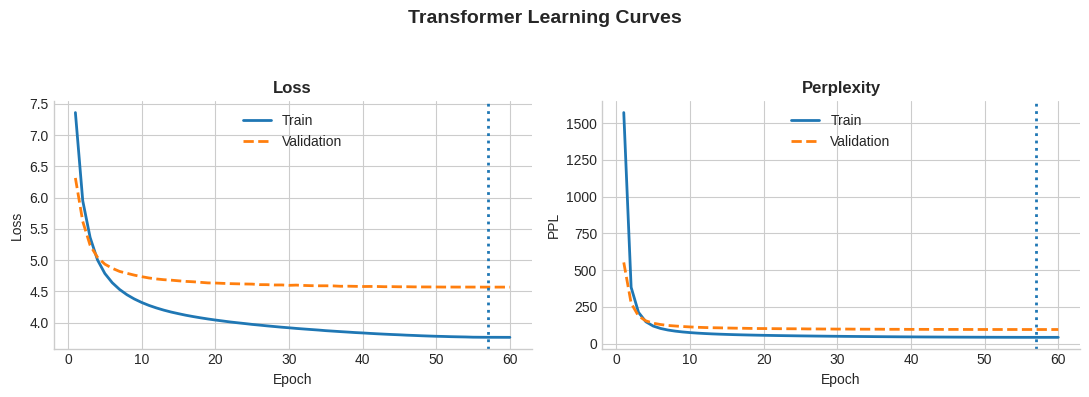

In [52]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(11,4))

# tiêu đề tổng
plt.suptitle("Transformer Learning Curves", fontsize=14, fontweight='bold')

ep      = [h['epoch'] for h in tf_history]
tr_loss = [h['train_loss'] for h in tf_history]
vl_loss = [h['val_loss'] for h in tf_history]
tr_ppl  = [h['train_ppl'] for h in tf_history]
vl_ppl  = [h['val_ppl'] for h in tf_history]

best_ep = tf_early_stop.best_epoch

# --- Loss ---
ax1 = plt.subplot(1,2,1)
ax1.plot(ep, tr_loss, linewidth=2, label='Train')
ax1.plot(ep, vl_loss, linewidth=2, linestyle='--', label='Validation')
ax1.axvline(best_ep, linestyle=':', linewidth=2)

ax1.set_title("Loss", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(frameon=False)
ax1.spines[['top','right']].set_visible(False)

# --- PPL ---
ax2 = plt.subplot(1,2,2)
ax2.plot(ep, tr_ppl, linewidth=2, label='Train')
ax2.plot(ep, vl_ppl, linewidth=2, linestyle='--', label='Validation')
ax2.axvline(best_ep, linestyle=':', linewidth=2)

ax2.set_title("Perplexity", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("PPL")
ax2.legend(frameon=False)
ax2.spines[['top','right']].set_visible(False)

# tránh bị đè tiêu đề
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()


<a id='sec7'></a>
## 7. So sánh kết quả

In [24]:
n_lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
n_tf_params   = sum(p.numel() for p in tf_model.parameters()   if p.requires_grad)

print('=' * 72)
print(f"{'Chỉ số':<30} {'LSTM (Baseline)':>18} {'Transformer':>18}")
print('-' * 72)
print(f"{'Kiến trúc':<30} {'Emb→LSTM×2→FC':>18} {'Emb+PE→TF×4→FC':>18}")
print(f"{'Tokenizer':<30} {'BPE':>18} {'BPE':>18}")
print(f"{'Vocab size':<30} {VOCAB_SIZE:>18,} {VOCAB_SIZE:>18,}")
print(f"{'seq_len':<30} {SEQ_LEN:>18} {SEQ_LEN:>18}")
print(f"{'d / hidden':<30} {str(LSTM_EMBED)+'/'+str(LSTM_HIDDEN):>18} {str(TF_DMODEL):>18}")
print(f"{'Optimizer':<30} {'Adam+ReduceLR':>18} {'AdamW+Warmup':>18}")
print(f"{'Early Stopping':<30} {'patience='+str(LSTM_PAT):>18} {'patience='+str(TF_PAT):>18}")
print(f"{'Số tham số':<30} {n_lstm_params:>18,} {n_tf_params:>18,}")
print(f"{'Best Epoch':<30} {lstm_early_stop.best_epoch:>18} {tf_early_stop.best_epoch:>18}")
print(f"{'Val PPL ↓':<30} {lstm_val_ppl:>18.2f} {tf_val_ppl:>18.2f}")
print(f"{'Test PPL ↓':<30} {lstm_test_ppl:>18.2f} {tf_test_ppl:>18.2f}")
print('=' * 72)

winner = 'Transformer' if tf_test_ppl < lstm_test_ppl else 'LSTM'
ratio  = max(lstm_test_ppl, tf_test_ppl) / min(lstm_test_ppl, tf_test_ppl)
print(f"\nMô hình tốt hơn: {winner} ({ratio:.1f}× về Test PPL)")
print(f"   → Transformer học long-range dependency tốt hơn nhờ self-attention")
print(f"   → LSTM bị giới hạn bởi sequential processing, dễ quên ngữ cảnh xa")

Chỉ số                            LSTM (Baseline)        Transformer
------------------------------------------------------------------------
Kiến trúc                           Emb→LSTM×2→FC     Emb+PE→TF×4→FC
Tokenizer                                     BPE                BPE
Vocab size                                 10,000             10,000
seq_len                                       128                128
d / hidden                               256/1024                256
Optimizer                           Adam+ReduceLR       AdamW+Warmup
Early Stopping                         patience=5         patience=8
Số tham số                             26,457,872          5,719,552
Best Epoch                                      5                 57
Val PPL ↓                                  329.65              96.47
Test PPL ↓                                 333.51              97.13

Mô hình tốt hơn: Transformer (3.4× về Test PPL)
   → Transformer học long-range dependency tốt hơn

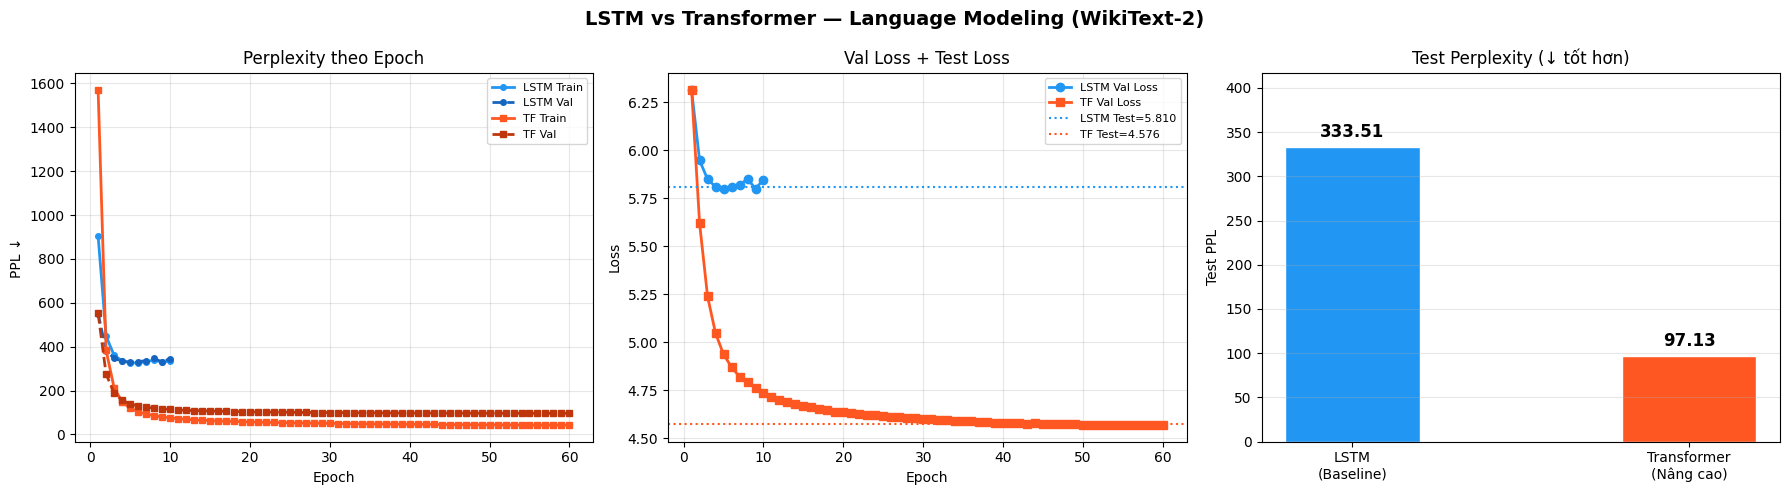

Lưu: comparison.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('LSTM vs Transformer — Language Modeling (WikiText-2)', fontsize=14, fontweight='bold')

ep_l = [h['epoch'] for h in lstm_history]
ep_t = [h['epoch'] for h in tf_history]
CL, CD, GL, GD = '#2196F3', '#1565C0', '#FF5722', '#BF360C'

# Perplexity theo epoch
axes[0].plot(ep_l, [h['train_ppl'] for h in lstm_history], 'o-',  color=CL, ms=4, lw=2, label='LSTM Train')
axes[0].plot(ep_l, [h['val_ppl']   for h in lstm_history], 'o--', color=CD, ms=4, lw=2, label='LSTM Val')
axes[0].plot(ep_t, [h['train_ppl'] for h in tf_history],   's-',  color=GL, ms=4, lw=2, label='TF Train')
axes[0].plot(ep_t, [h['val_ppl']   for h in tf_history],   's--', color=GD, ms=4, lw=2, label='TF Val')
axes[0].set_title('Perplexity theo Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('PPL ↓')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Val Loss + Test Loss
axes[1].plot(ep_l, [h['val_loss'] for h in lstm_history], 'o-',  color=CL, lw=2, label='LSTM Val Loss')
axes[1].plot(ep_t, [h['val_loss'] for h in tf_history],   's-',  color=GL, lw=2, label='TF Val Loss')
axes[1].axhline(lstm_test_loss, color=CL, ls=':', lw=1.5, label=f'LSTM Test={lstm_test_loss:.3f}')
axes[1].axhline(tf_test_loss,   color=GL, ls=':', lw=1.5, label=f'TF Test={tf_test_loss:.3f}')
axes[1].set_title('Val Loss + Test Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Test PPL bar chart
bars = axes[2].bar(
    ['LSTM\n(Baseline)', 'Transformer\n(Nâng cao)'],
    [lstm_test_ppl, tf_test_ppl],
    color=[CL, GL], width=0.4, edgecolor='white'
)
axes[2].bar_label(bars, fmt='%.2f', padding=4, fontsize=12, fontweight='bold')
axes[2].set_title('Test Perplexity (↓ tốt hơn)'); axes[2].set_ylabel('Test PPL')
axes[2].set_ylim(0, max(lstm_test_ppl, tf_test_ppl) * 1.25)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lưu: comparison.png")

<a id='sec8'></a>
## 8. Thí nghiệm: Optimizer & Regularization

So sánh 3 cấu hình training trên LSTM để phân tích ảnh hưởng của optimizer và regularization:

| Config | Optimizer | Regularization |
|---|---|---|
| Config 1 | Adam (lr=3e-4) | Không có |
| Config 2 | Adam (lr=3e-4) | Dropout(0.3) |
| Config 3 | SGD (lr=0.1, momentum=0.9) | Dropout(0.3) |

In [26]:
def train_one_config(config_name, optimizer_fn, dropout=0.0, epochs=10, patience=3):
    """Train LSTM với 1 cấu hình và trả về kết quả."""
    model = LSTM_LM(
        vocab_size = VOCAB_SIZE,
        embed_dim  = LSTM_EMBED,
        hidden_dim = LSTM_HIDDEN,
        num_layers = LSTM_LAYERS,
        dropout    = dropout
    ).to(DEVICE)

    opt      = optimizer_fn(model.parameters())
    sched    = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)
    tmp_path = SAVE_DIR / f'tmp_{config_name.replace(" ","_").replace(",","")}.pt'
    early    = EarlyStopping(patience=patience, save_path=tmp_path, name=config_name)
    history  = []

    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()
            total += loss.item()

        tl = total / len(train_loader)
        tp = math.exp(min(tl, 20))
        vl, vp = evaluate(model, val_loader)
        sched.step(vl)
        history.append(dict(epoch=epoch, train_ppl=tp, val_ppl=vp,
                             train_loss=tl, val_loss=vl))
        print(f"  [{config_name}] Ep {epoch:02d} | Train PPL: {tp:.2f} | Val PPL: {vp:.2f}")
        if early(vl, model, epoch):
            print(f"  Early stop @ epoch {epoch}")
            break

    # ✅ Load best checkpoint trước khi evaluate test
    if tmp_path.exists():
        model.load_state_dict(torch.load(tmp_path, map_location=DEVICE, weights_only=True))
    _, test_ppl = evaluate(model, test_loader)
    be = early.best_epoch
    return dict(
        name       = config_name,
        train_ppl  = history[be-1]['train_ppl'],
        val_ppl    = math.exp(min(early.best_loss, 20)),
        test_ppl   = test_ppl,
        best_epoch = be,
        history    = history
    )

print("train_one_config() sẵn sàng")

train_one_config() sẵn sàng


In [37]:
# Chạy 3 config thí nghiệm
exp_configs = [
    ('Adam, no regularization',
     lambda p: optim.Adam(p, lr=3e-4, weight_decay=0.0), 0.0),
    ('Adam + Dropout(0.3)',
     lambda p: optim.Adam(p, lr=3e-4, weight_decay=1e-4), 0.3),
    ('SGD + Dropout(0.3)',
     lambda p: optim.SGD(p, lr=0.1, momentum=0.9, nesterov=True), 0.3),
]

exp_results = []
for name, opt_fn, drop in exp_configs:
    print(f"\n{'='*60}\n  Config: {name}\n{'='*60}")
    r = train_one_config(name, opt_fn, dropout=drop, epochs=10, patience=3)
    exp_results.append(r)

# Bảng tổng hợp
print('\n' + '=' * 72)
print(f"{'Cấu hình':<32} {'Train PPL':>10} {'Val PPL':>10} {'Test PPL':>10} {'Best Ep':>8}")
print('-' * 72)
for r in exp_results:
    print(f"{r['name']:<32} {r['train_ppl']:>10.2f} {r['val_ppl']:>10.2f} "
          f"{r['test_ppl']:>10.2f} {r['best_epoch']:>8}")
print('=' * 72)

print("\nNhận xét:")
print("  - Adam không có regularization: hội tụ nhanh nhất nhưng gap train/val lớn → overfit")
print("  - Adam + Dropout: giảm overfit, gap train/val nhỏ hơn")
print("  - SGD + Dropout: hội tụ chậm hơn nhưng ổn định hơn, ít overfit")


  Config: Adam, no regularization
  [Adam, no regularization] Ep 01 | Train PPL: 908.38 | Val PPL: 578.64
   [Adam, no regularization] Best saved — val_ppl=578.64 (epoch 1)
  [Adam, no regularization] Ep 02 | Train PPL: 455.55 | Val PPL: 411.03
   [Adam, no regularization] Best saved — val_ppl=411.03 (epoch 2)
  [Adam, no regularization] Ep 03 | Train PPL: 338.15 | Val PPL: 339.75
   [Adam, no regularization] Best saved — val_ppl=339.75 (epoch 3)
  [Adam, no regularization] Ep 04 | Train PPL: 273.37 | Val PPL: 297.80
   [Adam, no regularization] Best saved — val_ppl=297.80 (epoch 4)
  [Adam, no regularization] Ep 05 | Train PPL: 231.00 | Val PPL: 266.33
   [Adam, no regularization] Best saved — val_ppl=266.33 (epoch 5)
  [Adam, no regularization] Ep 06 | Train PPL: 200.71 | Val PPL: 245.24
   [Adam, no regularization] Best saved — val_ppl=245.24 (epoch 6)
  [Adam, no regularization] Ep 07 | Train PPL: 177.37 | Val PPL: 227.30
   [Adam, no regularization] Best saved — val_ppl=227.30 (e

/tmp/ipykernel_1536/2303234973.py:30: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1536/2303234973.py:31: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.savefig(SAVE_DIR / 'experiment_optimizer.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


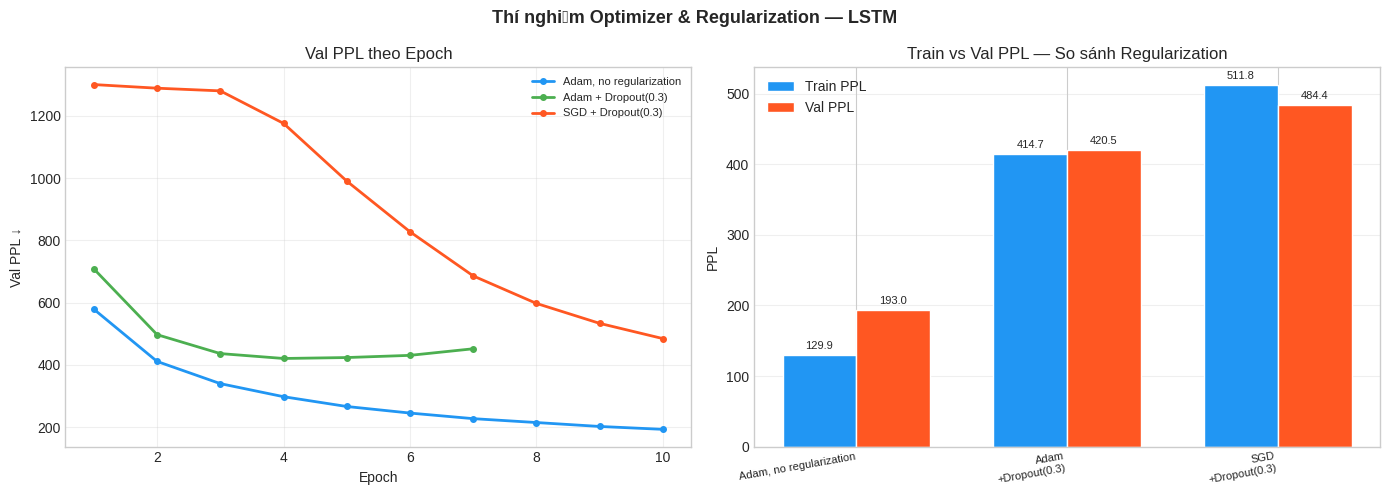

Lưu: experiment_optimizer.png


In [38]:
# Vẽ so sánh Val PPL giữa 3 config
colors = ['#2196F3', '#4CAF50', '#FF5722']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Thí nghiệm Optimizer & Regularization — LSTM', fontsize=13, fontweight='bold')

# Val PPL theo epoch
for r, c in zip(exp_results, colors):
    eps  = [h['epoch']   for h in r['history']]
    vppl = [h['val_ppl'] for h in r['history']]
    axes[0].plot(eps, vppl, 'o-', color=c, lw=2, ms=4, label=r['name'])
axes[0].set_title('Val PPL theo Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val PPL ↓')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Bar chart Train vs Val PPL
names      = [r['name'].replace(' + ', '\n+') for r in exp_results]
train_ppls = [r['train_ppl'] for r in exp_results]
val_ppls   = [r['val_ppl']   for r in exp_results]
x = list(range(len(names)))
w = 0.35
b1 = axes[1].bar([i - w/2 for i in x], train_ppls, w, label='Train PPL',
                 color='#2196F3', edgecolor='white')
b2 = axes[1].bar([i + w/2 for i in x], val_ppls,   w, label='Val PPL',
                 color='#FF5722', edgecolor='white')
axes[1].bar_label(b1, fmt='%.1f', padding=3, fontsize=8)
axes[1].bar_label(b2, fmt='%.1f', padding=3, fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=10, ha='right', fontsize=8)
axes[1].set_title('Train vs Val PPL — So sánh Regularization')
axes[1].set_ylabel('PPL'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'experiment_optimizer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lưu: experiment_optimizer.png")

<a id='sec9'></a>
## 9. Sinh văn bản & Phân tích lỗi

Sinh 8 mẫu văn bản từ cả 2 model với cùng prompt, sau đó phân tích:
- **TTR** (Type-Token Ratio): tỷ lệ từ duy nhất — cao hơn = đa dạng hơn
- **Bigram lặp**: đếm cụm 2 từ bị lặp — thấp hơn = ít lặp hơn

In [39]:
def generate(model, prompt, max_tokens=30, temperature=0.8, top_k=10):
    """
    Sinh văn bản autoregressive với top-k sampling.
    Dùng chung cho cả LSTM và Transformer — interface giống nhau:
      logits = model(x)  →  shape (B=1, T, vocab_size)
    Args:
        model       : LSTM_LM hoặc TransformerLM
        prompt      : chuỗi văn bản khởi đầu
        max_tokens  : số token sinh thêm
        temperature : > 1 = đa dạng hơn, < 1 = tập trung hơn
        top_k       : chỉ sample trong k token xác suất cao nhất
    """
    model.eval()
    tokens = encode(prompt)
    if not tokens:
        tokens = [UNK_ID]

    for _ in range(max_tokens):
        x = torch.tensor(tokens[-SEQ_LEN:], dtype=torch.long).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(x)[0, -1] / temperature   # (vocab_size,)
        # Top-k masking: đặt -inf cho tất cả token ngoài top-k
        if top_k > 0:
            top_vals, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < top_vals[-1]] = float('-inf')
        probs      = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1).item()
        tokens.append(next_token)

    return decode(tokens)


# Backward-compatible aliases (dùng trong cell sinh văn bản)
generate_lstm        = lambda model, prompt, **kw: generate(model, prompt, **kw)
generate_transformer = lambda model, prompt, **kw: generate(model, prompt, **kw)

print("generate() sẵn sàng — dùng chung cho LSTM và Transformer")
print("   temperature=0.8 | top_k=10")

generate() sẵn sàng — dùng chung cho LSTM và Transformer
   temperature=0.8 | top_k=10


In [49]:
# Sinh 8 mẫu từ cả 2 model
PROMPTS = [
    'the history of',
    'in the early',
    'scientists discovered',
    'the war began',
    'he was born in',
    'according to the report',
    'the government decided',
    'in recent years',
]

lstm_samples = []
tf_samples   = []

print('=' * 75)
print('SO SÁNH VĂN BẢN SINH — LSTM vs Transformer (temperature=0.8, top_k=10)')
print('=' * 75)

for i, prompt in enumerate(PROMPTS, 1):
    lstm_out = generate_lstm(lstm_model, prompt, max_tokens=25)
    tf_out   = generate_transformer(tf_model,   prompt, max_tokens=25)
    lstm_samples.append(lstm_out)
    tf_samples.append(tf_out)
    print(f"\n[{i}] Prompt      : '{prompt}'")
    print(f"    LSTM        : {lstm_out}")
    print(f"    Transformer : {tf_out}")

print('\n' + '=' * 75)

SO SÁNH VĂN BẢN SINH — LSTM vs Transformer (temperature=0.8, top_k=10)

[1] Prompt      : 'the history of'
    LSTM        : the history of the city and the most of the city . The most of the United States was a first of the American , the city was
    Transformer : the history of the Great Western Front . = = = First World War = = = During the Gall ip oli Camp aign , the Battle of

[2] Prompt      : 'in the early'
    LSTM        : in the early , but he was a " for a " , " The P ave " , " The song " . The album , and
    Transformer : in the early stages of the series , the series was re @-@ released on May 11 , 2012 . It was released on May 25 , 2012

[3] Prompt      : 'scientists discovered'
    LSTM        : scientists discovered in the city ' s the year . It was not not in the first time of the first half of the season to the
    Transformer : scientists discovered that the first time they were discovered in a large number of other researchers , including the possibility that they

In [50]:
# Phân tích lỗi lặp
def analyze_generation(model_name, samples):
    all_words  = ' '.join(samples).split()
    ttr        = len(set(all_words)) / max(len(all_words), 1)
    bigram_rep = 0
    for s in samples:
        words   = s.split()
        bigrams = [(words[i], words[i+1]) for i in range(len(words)-1)]
        counts  = Counter(bigrams)
        bigram_rep += sum(c - 1 for c in counts.values() if c > 1)

    print(f"  {'─'*48}")
    print(f"  {model_name}")
    print(f"  {'─'*48}")
    print(f"  TTR (Type-Token Ratio)  : {ttr:.3f}  (↑ đa dạng hơn)")
    print(f"  Bigram lặp (tổng)       : {bigram_rep}  (↓ ít lặp hơn)")
    if ttr < 0.3:   print("  TTR thấp → lặp từ nhiều")
    elif ttr < 0.5: print("  TTR trung bình")
    else:           print("  TTR tốt")
    return ttr, bigram_rep

print("Phân tích chất lượng văn bản sinh:")
lstm_ttr, lstm_brep = analyze_generation('LSTM (Baseline)',       lstm_samples)
tf_ttr,   tf_brep   = analyze_generation('Transformer (Nâng cao)', tf_samples)



Phân tích chất lượng văn bản sinh:
  ────────────────────────────────────────────────
  LSTM (Baseline)
  ────────────────────────────────────────────────
  TTR (Type-Token Ratio)  : 0.311  (↑ đa dạng hơn)
  Bigram lặp (tổng)       : 27  (↓ ít lặp hơn)
  TTR trung bình
  ────────────────────────────────────────────────
  Transformer (Nâng cao)
  ────────────────────────────────────────────────
  TTR (Type-Token Ratio)  : 0.484  (↑ đa dạng hơn)
  Bigram lặp (tổng)       : 24  (↓ ít lặp hơn)
  TTR trung bình


/tmp/ipykernel_1536/3107457301.py:19: UserWarning: Glyph 417 (\N{LATIN SMALL LETTER O WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1536/3107457301.py:19: UserWarning: Glyph 7841 (\N{LATIN SMALL LETTER A WITH DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1536/3107457301.py:19: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1536/3107457301.py:19: UserWarning: Glyph 7863 (\N{LATIN SMALL LETTER A WITH BREVE AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1536/3107457301.py:19: UserWarning: Glyph 7845 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1536/3107457301.py:19: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/t

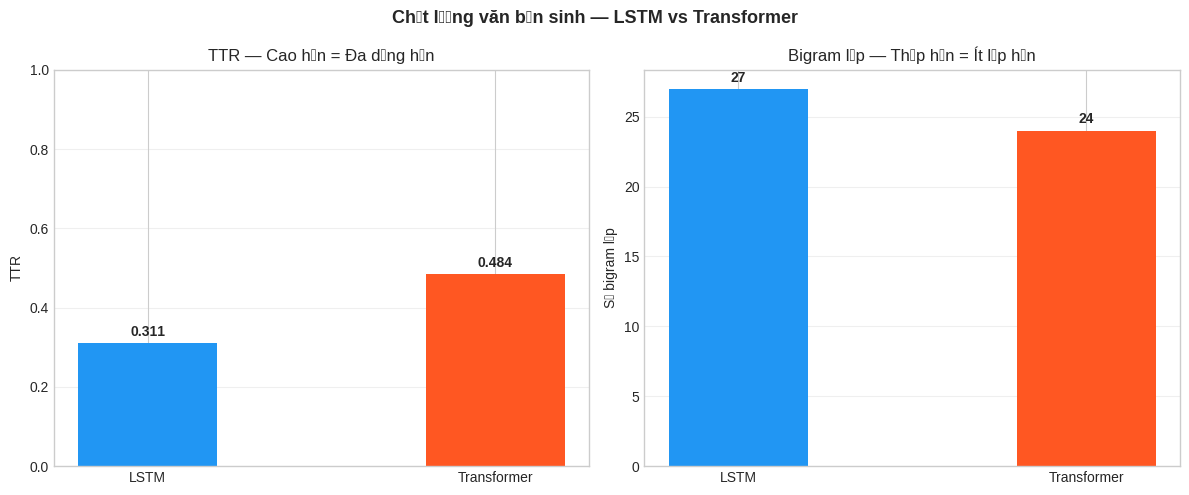

Lưu: generation_quality.png


In [51]:
# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Chất lượng văn bản sinh — LSTM vs Transformer', fontsize=13, fontweight='bold')

b0 = axes[0].bar(['LSTM', 'Transformer'], [lstm_ttr, tf_ttr],
                 color=['#2196F3', '#FF5722'], width=0.4)
axes[0].bar_label(b0, fmt='%.3f', padding=3, fontweight='bold')
axes[0].set_title('TTR — Cao hơn = Đa dạng hơn')
axes[0].set_ylabel('TTR'); axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

b1 = axes[1].bar(['LSTM', 'Transformer'], [lstm_brep, tf_brep],
                 color=['#2196F3', '#FF5722'], width=0.4)
axes[1].bar_label(b1, padding=3, fontweight='bold')
axes[1].set_title('Bigram lặp — Thấp hơn = Ít lặp hơn')
axes[1].set_ylabel('Số bigram lặp')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'generation_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lưu: generation_quality.png")

<a id='sec10'></a>
## 10. Kết luận

In [42]:
n_lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
n_tf_params   = sum(p.numel() for p in tf_model.parameters()   if p.requires_grad)

print('=' * 72)
print('  ĐỒ ÁN #21 — LANGUAGE MODELING MINI — KẾT QUẢ CUỐI CÙNG')
print('=' * 72)
print(f"  Dataset    : WikiText-2 | BPE vocab={VOCAB_SIZE:,} | seq_len={SEQ_LEN} | stride={STRIDE}")
print()
print(f"  MÔ HÌNH 1 — LSTM Baseline (2-layer)")
print(f"  ├─ Kiến trúc : Embedding({LSTM_EMBED}) → LSTM×{LSTM_LAYERS}({LSTM_HIDDEN}) → Dropout({LSTM_DROP}) → FC")
print(f"  ├─ Optimizer : Adam(lr={LSTM_LR}) + ReduceLROnPlateau + Early Stop(p={LSTM_PAT})")
print(f"  ├─ Tham số   : {n_lstm_params:,}")
print(f"  ├─ Best Epoch: {lstm_early_stop.best_epoch}")
print(f"  ├─ Val PPL   : {lstm_val_ppl:.2f}")
print(f"  └─ Test PPL  : {lstm_test_ppl:.2f}")
print()
print(f"  MÔ HÌNH 2 — Transformer Decoder Mini (Nâng cao)")
print(f"  ├─ Kiến trúc : Emb+PE → {TF_LAYERS}×Block(d={TF_DMODEL},{TF_HEADS}h) → FC(weight-tied)")
print(f"  ├─ Optimizer : AdamW(lr={TF_LR},wd=0.1) + Warmup(2ep) + Cosine Decay")
print(f"  ├─ Tham số   : {n_tf_params:,}")
print(f"  ├─ Best Epoch: {tf_early_stop.best_epoch}")
print(f"  ├─ Val PPL   : {tf_val_ppl:.2f}")
print(f"  └─ Test PPL  : {tf_test_ppl:.2f}")
print()

if tf_test_ppl < lstm_test_ppl:
    ratio = lstm_test_ppl / tf_test_ppl
    print(f"  Transformer tốt hơn LSTM ~{ratio:.1f}× về Test PPL")
    print(f"     → Self-attention học long-range dependency tốt hơn LSTM")
    print(f"     → Pre-LN + weight tying giúp training ổn định, ít tham số hơn")
else:
    ratio = tf_test_ppl / lstm_test_ppl
    print(f"  LSTM cạnh tranh tốt (Transformer cao hơn {ratio:.1f}×)")
    print(f"     → Orthogonal init + gradient clipping giúp LSTM generalize tốt")
print()
print("  Hướng phát triển:")
print("  - Subword tokenization đã dùng BPE → có thể thử SentencePiece (unigram)")
print("  - Tăng data: WikiText-103 hoặc thêm TinyStories (tùy chọn theo đề bài)")
print("  - Beam search cho generation chất lượng cao hơn temperature sampling")
print("  - Tăng model size: d=512, 6 layers nếu có GPU mạnh hơn")
print('=' * 72)

  ĐỒ ÁN #21 — LANGUAGE MODELING MINI — KẾT QUẢ CUỐI CÙNG
  Dataset    : WikiText-2 | BPE vocab=10,000 | seq_len=128 | stride=64

  MÔ HÌNH 1 — LSTM Baseline (2-layer)
  ├─ Kiến trúc : Embedding(256) → LSTM×2(1024) → Dropout(0.5) → FC
  ├─ Optimizer : Adam(lr=0.0005) + ReduceLROnPlateau + Early Stop(p=5)
  ├─ Tham số   : 26,457,872
  ├─ Best Epoch: 5
  ├─ Val PPL   : 329.65
  └─ Test PPL  : 333.51

  MÔ HÌNH 2 — Transformer Decoder Mini (Nâng cao)
  ├─ Kiến trúc : Emb+PE → 4×Block(d=256,4h) → FC(weight-tied)
  ├─ Optimizer : AdamW(lr=0.0005,wd=0.1) + Warmup(2ep) + Cosine Decay
  ├─ Tham số   : 5,719,552
  ├─ Best Epoch: 57
  ├─ Val PPL   : 96.47
  └─ Test PPL  : 97.13

  Transformer tốt hơn LSTM ~3.4× về Test PPL
     → Self-attention học long-range dependency tốt hơn LSTM
     → Pre-LN + weight tying giúp training ổn định, ít tham số hơn

  Hướng phát triển:
  - Subword tokenization đã dùng BPE → có thể thử SentencePiece (unigram)
  - Tăng data: WikiText-103 hoặc thêm TinyStories (tùy 

In [43]:
# Lưu metadata
import json
meta = {
    'vocab_size'       : VOCAB_SIZE,
    'seq_len'          : SEQ_LEN,
    'stride'           : STRIDE,
    'batch_size'       : BATCH_SIZE,
    'lstm_params'      : n_lstm_params,
    'tf_params'        : n_tf_params,
    'lstm_best_epoch'  : lstm_early_stop.best_epoch,
    'lstm_val_ppl'     : round(lstm_val_ppl,  2),
    'lstm_test_ppl'    : round(lstm_test_ppl, 2),
    'tf_best_epoch'    : tf_early_stop.best_epoch,
    'tf_val_ppl'       : round(tf_val_ppl,    2),
    'tf_test_ppl'      : round(tf_test_ppl,   2),
    'exp_results'      : [{
        'name': r['name'], 'train_ppl': round(r['train_ppl'],2),
        'val_ppl': round(r['val_ppl'],2), 'test_ppl': round(r['test_ppl'],2)
    } for r in exp_results]
}
with open(SAVE_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f"Đã lưu tất cả vào {SAVE_DIR}:")
for f in sorted(SAVE_DIR.iterdir()):
    size_kb = f.stat().st_size / 1e3
    print(f"   {f.name:<45} ({size_kb:.0f} KB)")

Đã lưu tất cả vào /content/drive/MyDrive/do_an_21:
   bpe_tokenizer.json                            (616 KB)
   comparison.png                                (131 KB)
   eda_dataset.png                               (100 KB)
   experiment_optimizer.png                      (113 KB)
   fig4_5_lr_schedule.png                        (79 KB)
   fig5_1_lstm_ppl.png                           (78 KB)
   fig5_2_lstm_curves.png                        (156 KB)
   fig5_3_transformer_curves.png                 (154 KB)
   generation_quality.png                        (48 KB)
   lstm_best.pt                                  (105835 KB)
   metadata.json                                 (1 KB)
   tf_best.pt                                    (23422 KB)
   tmp_Adam_+_Dropout(0.3).pt                    (105835 KB)
   tmp_Adam_no_regularization.pt                 (105835 KB)
   tmp_SGD_+_Dropout(0.3).pt                     (105835 KB)
